## 1) Load the Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import math

from pandas.api.types import CategoricalDtype

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [ ]:
studGrades = pd.read_csv('/content/StudentsPerformance.csv')

In [ ]:
studGrades.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
studGrades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
studGrades.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
studGrades.isna().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


## 2) Clean
* data has no missing values
* categorical columns don't have typos in each feature

### check the typoes in each object columns

In [ ]:
obj_features = studGrades.columns[studGrades.dtypes == object]
numirecal_features = studGrades.columns[studGrades.dtypes != object]
obj_features, numirecal_features

(Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course'],
       dtype='object'),
 Index(['math score', 'reading score', 'writing score'], dtype='object'))

In [ ]:
for col in obj_features:
    print(studGrades[col].value_counts())

gender
female    518
male      482
Name: count, dtype: int64
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
test preparation course
none         642
completed    358
Name: count, dtype: int64


## 3)EDA

###Univariant features explore

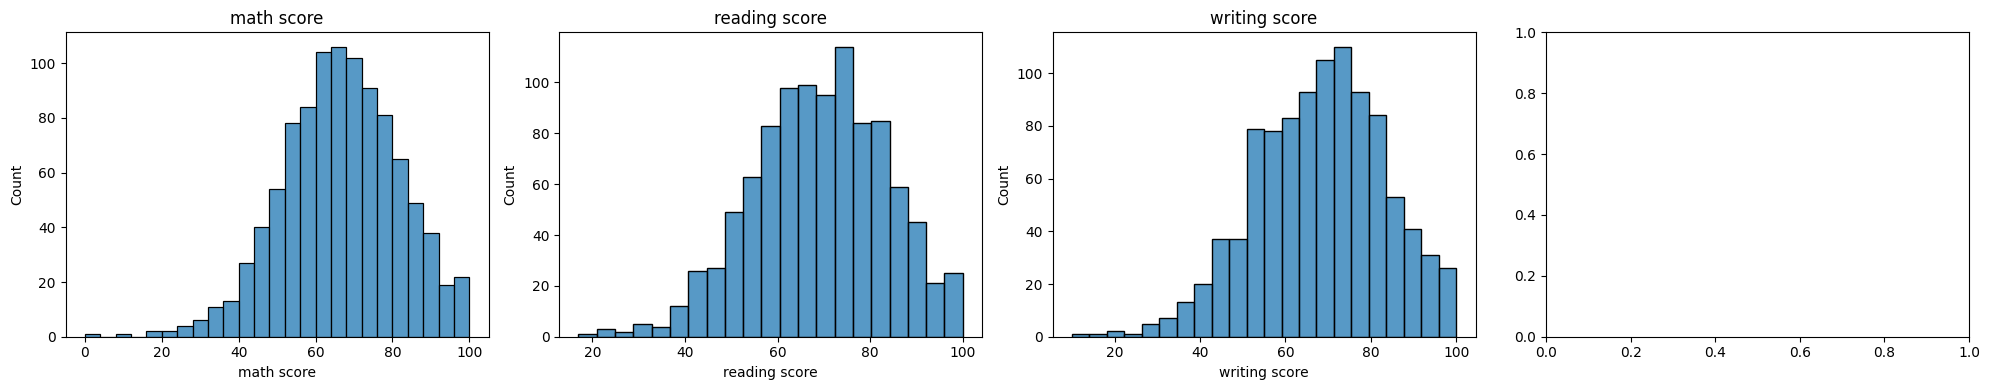

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax = ax.flatten()
for i, col in enumerate(numirecal_features):
    sns.histplot(studGrades[col], ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()
plt.show()

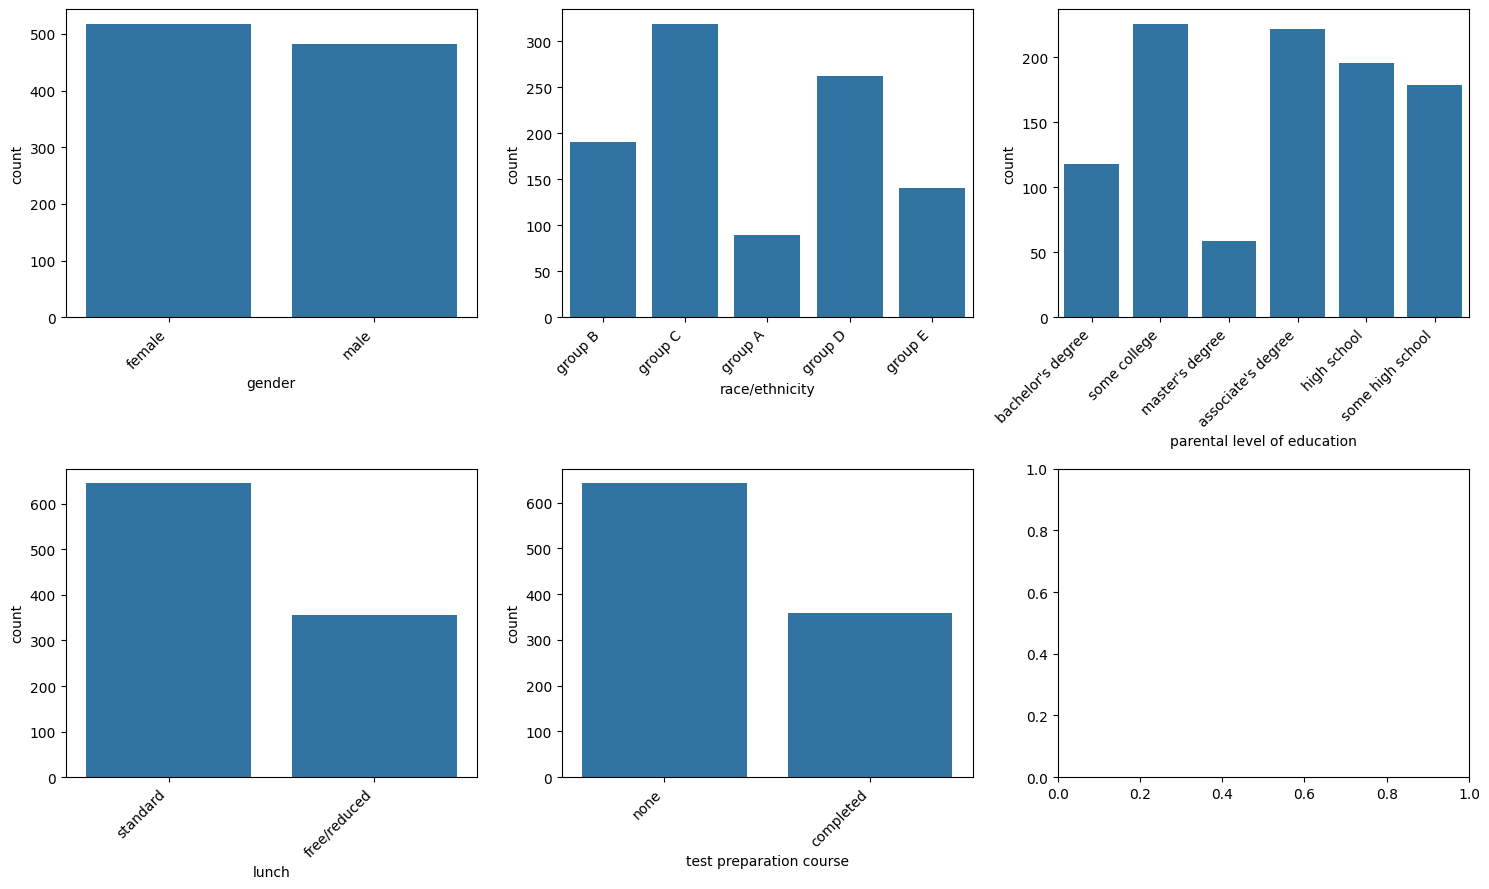

In [ ]:
obj_features = studGrades.columns[studGrades.dtypes == object]
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
ax = ax.flatten()

for i, col in enumerate(obj_features):
    sns.countplot(x=col, data=studGrades, ax=ax[i])
    current_tick_locations = ax[i].get_xticks()
    ax[i].set_xticks(current_tick_locations)
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
skewness = []
for col in numirecal_features:
    level = stats.skew(studGrades[col])
    need_transform = level > 1 or level < -1
    skewness.append({
        'feature': col,
        'level': level,
        'needs_transform': 'Yes' if need_transform else 'No'
    })
print(pd.DataFrame(skewness))

         feature     level needs_transform
0     math score -0.278517              No
1  reading score -0.258716              No
2  writing score -0.289010              No


### bivariate features explore

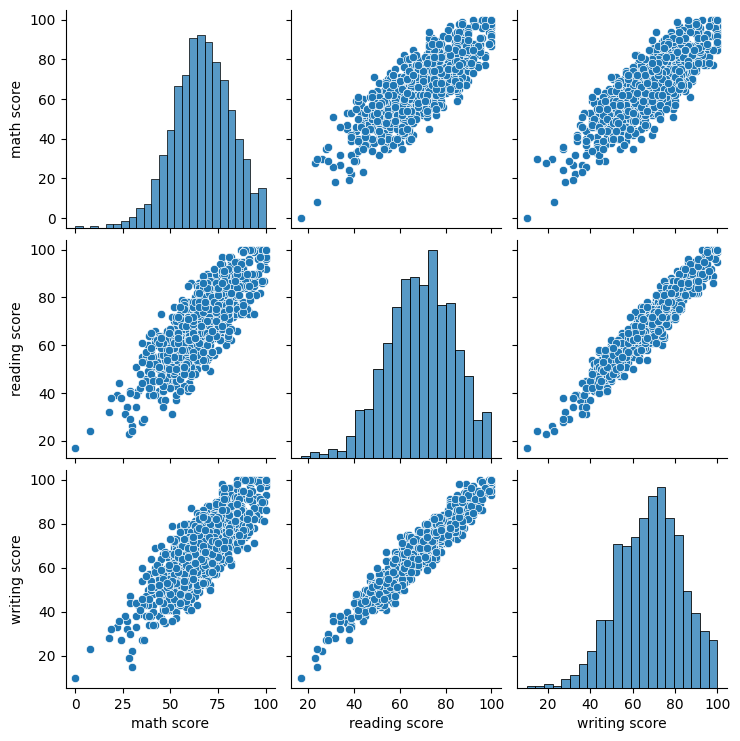

In [ ]:
sns.pairplot(studGrades)
plt.show()

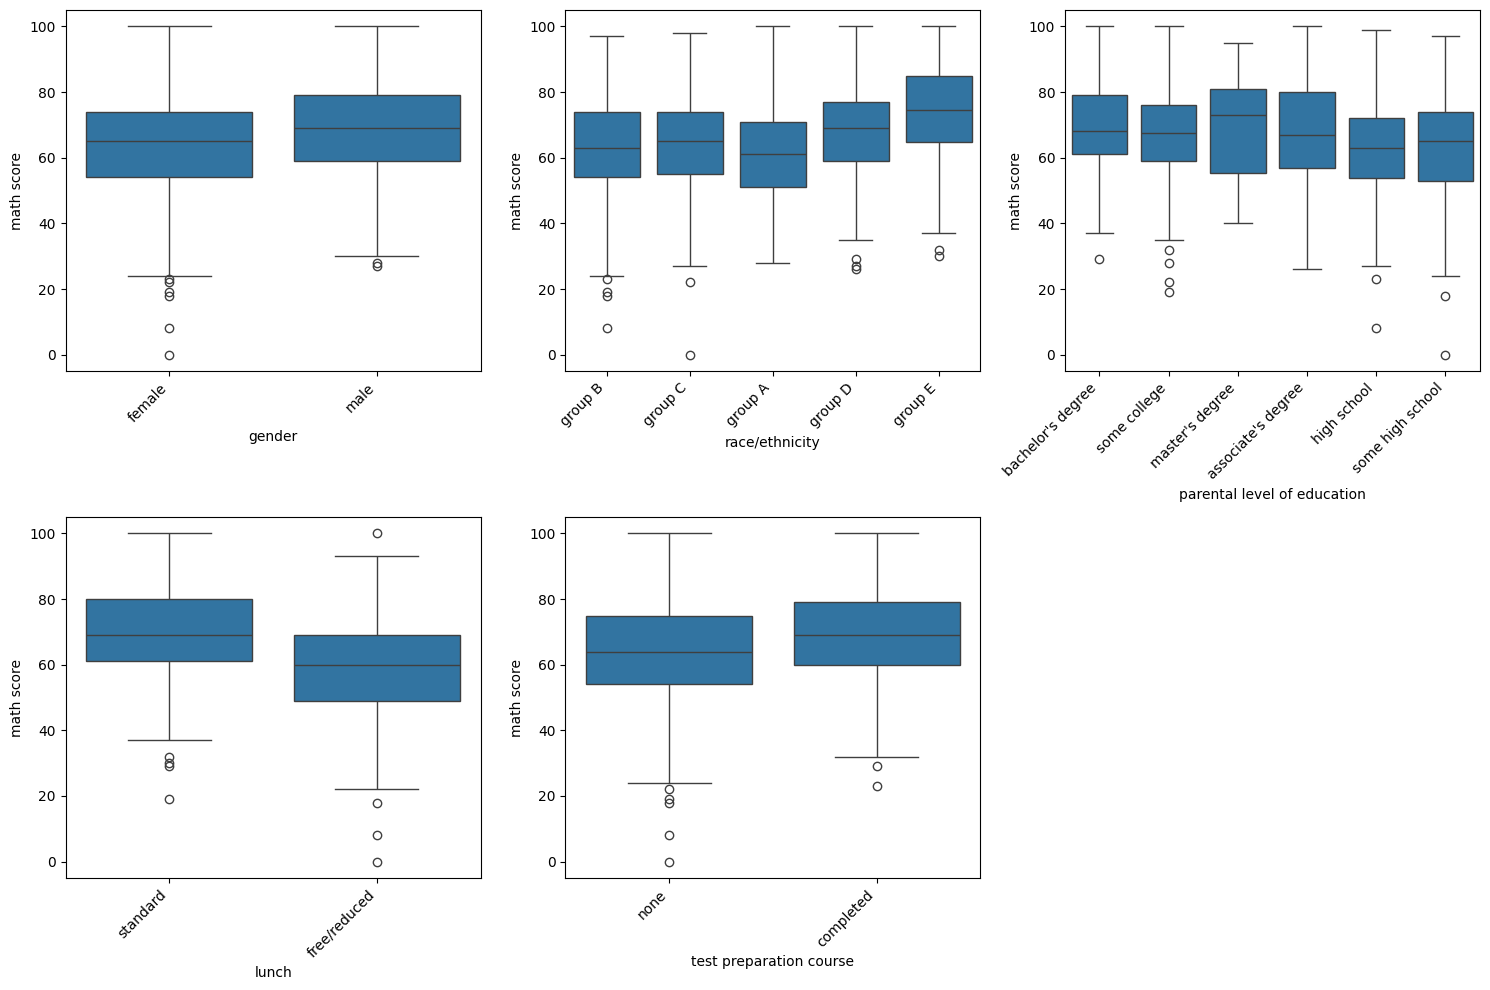

In [ ]:
n_cols = 3
n_rows = math.ceil(len(obj_features) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
ax = ax.flatten() # Assign the flattened array back to ax

for i, col in enumerate(obj_features):
    sns.boxplot(x=col, y='math score', data=studGrades, ax=ax[i])
    current_tick_locations = ax[i].get_xticks()
    ax[i].set_xticks(current_tick_locations)
    ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45, ha='right')

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

### correlation

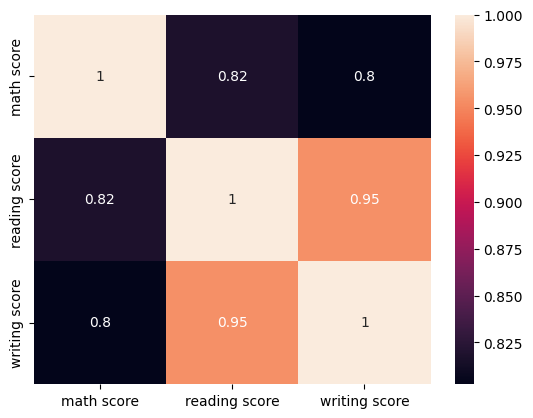

In [ ]:
sns.heatmap(studGrades.corr(numeric_only=True), annot=True)
plt.show()


## 3)feature engneering

### handle numerical features based on correlation and pair plots
* reading and writing has a strong relation so we don't need them together and i will use the avg score between them because it has more corr with target var(math score) and it uses them both without neglicting one of them

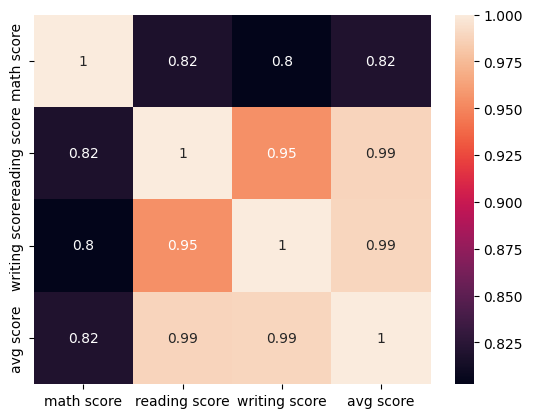

In [ ]:
studGrades['avg score'] = (studGrades['reading score'] + studGrades['writing score']) / 2
sns.heatmap(studGrades.corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
updated_studGrades = studGrades.drop(columns=['reading score', 'writing score'])

### handle categorical features based on hypothsis testing

In [ ]:
alpha = 0.05
results = []
for col in obj_features:
  groups = [studGrades.loc[studGrades[col] == level, 'math score']
          for level in studGrades[col].unique()]
  if len(groups) == 2:
    levene_p = stats.levene(*groups).pvalue
    test, p = stats.ttest_ind(*groups, equal_var=(levene_p > alpha))
    test_name = 'levene' if levene_p > alpha else 't-test'
  elif len(groups) > 2:
    test, p = stats.f_oneway(*groups)
    test_name = 'f-test'
  else:
    continue
  results.append({
      'feature': col,
      'test': test_name,
      'test_val': test,
      'p-value': p,
      'result': 'significant' if p < alpha else 'not significant'
  })
print(pd.DataFrame(results))


                       feature    test   test_val       p-value       result
0                       gender  levene  -5.383246  9.120186e-08  significant
1               race/ethnicity  f-test  14.593885  1.373219e-11  significant
2  parental level of education  f-test   6.521583  5.592272e-06  significant
3                        lunch  levene  11.837180  2.413196e-30  significant
4      test preparation course  levene  -5.704616  1.535913e-08  significant


* all categorical features have significant diffrance in mean between it's groups' values.

* all categorical features are useful

### features encoding

In [ ]:
updated_studGrades['gender_male'] = (studGrades['gender'] == 'male').astype(int)
updated_studGrades['lunch_standard'] = (studGrades['lunch'] == 'standard').astype(int)
updated_studGrades['test_prep_course'] = (studGrades['test preparation course'] == 'completed').astype(int)


race_ethnicity_categories = ['group A', 'group B', 'group C', 'group D', 'group E']
race_ethnicity_cat_type = CategoricalDtype(categories=race_ethnicity_categories, ordered=False)
updated_studGrades['race/ethnicity'] = studGrades['race/ethnicity'].astype(race_ethnicity_cat_type)
race_dummies = pd.get_dummies(updated_studGrades['race/ethnicity'], prefix='race', drop_first=True)
updated_studGrades = pd.concat([updated_studGrades, race_dummies], axis=1)

parental_edu_categories = ['some high school', 'high school', 'some college', "associate's degree", "bachelor's degree", "master's degree"]
parental_edu_cat_type = CategoricalDtype(categories=parental_edu_categories, ordered=True)
updated_studGrades['parental_edu'] = studGrades['parental level of education'].astype(parental_edu_cat_type).cat.codes


In [ ]:
updated_studGrades.drop(columns=['gender', 'lunch', 'test preparation course', 'race/ethnicity', 'parental level of education'], inplace=True)

In [ ]:
updated_studGrades.head()

,math score,avg score,gender_male,lunch_standard,test_prep_course,race_group B,race_group C,race_group D,race_group E,parental_edu
0,72,73.0,0,1,0,True,False,False,False,4
1,69,89.0,0,1,1,False,True,False,False,2
2,90,94.0,0,1,0,True,False,False,False,5
3,47,50.5,1,0,0,False,False,False,False,3
4,76,76.5,1,1,0,False,True,False,False,2


In [ ]:
updated_studGrades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   math score        1000 non-null   int64  
 1   avg score         1000 non-null   float64
 2   gender_male       1000 non-null   int64  
 3   lunch_standard    1000 non-null   int64  
 4   test_prep_course  1000 non-null   int64  
 5   race_group B      1000 non-null   bool   
 6   race_group C      1000 non-null   bool   
 7   race_group D      1000 non-null   bool   
 8   race_group E      1000 non-null   bool   
 9   parental_edu      1000 non-null   int8   
dtypes: bool(4), float64(1), int64(4), int8(1)
memory usage: 44.1 KB


## 4)Model building

In [ ]:
def model_evaluation(model, X_train, y_train, X_test, y_test):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)

    return train_mse, test_mse, train_r2, test_r2

In [ ]:
def print_model_evaluation(train_mse, test_mse, train_r2, test_r2):
    print(f'Train MSE: {train_mse}')
    print(f'Test MSE: {test_mse}')
    print(f'Train R2: {train_r2}')
    print(f'Test R2: {test_r2}')

### split the data

In [ ]:
X = updated_studGrades.drop(columns=['math score'])
y = updated_studGrades['math score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### base model (linear regression)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_scores = model_evaluation(lr, X_train, y_train, X_test, y_test)
print_model_evaluation(*lr_scores)

Train MSE: 29.419768636472938
Test MSE: 28.891127407778782
Train R2: 0.8695050046172221
Test R2: 0.8812718115686682


### linear regression after scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

lr_scaled_scores = model_evaluation(lr_scaled, X_train_scaled, y_train, X_test_scaled, y_test)
print_model_evaluation(*lr_scaled_scores)

Train MSE: 29.419768636472938
Test MSE: 28.891127407778786
Train R2: 0.8695050046172221
Test R2: 0.8812718115686682


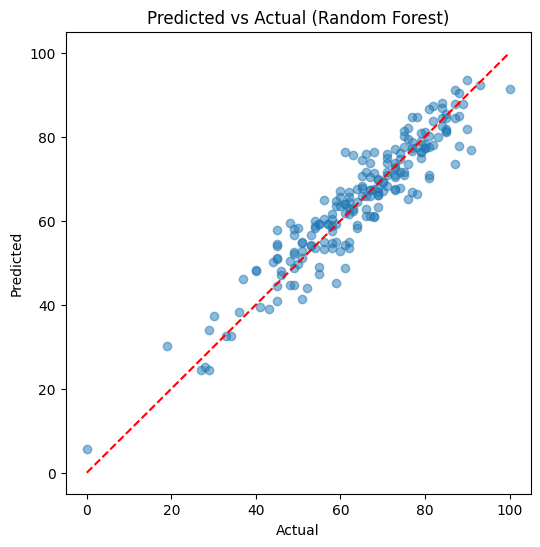

In [ ]:
plt.figure(figsize=(6,6))
y_pred_lr = lr.predict(X_test)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Random Forest)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()


###Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_scores = model_evaluation(rf, X_train, y_train, X_test, y_test)
print_model_evaluation(*rf_scores)


Train MSE: 5.985476985415427
Test MSE: 43.017857749572705
Train R2: 0.9734506820489683
Test R2: 0.8232179641619543


* random Forset model overfits on the training data

###RF hyperparamter tunning

In [ ]:
param_dist = {
    "n_estimators": [200],
    "max_depth": [None,1, 2, 3, 4, 5, 6, 7, 8, 10],
    "min_samples_leaf": [0.005],
    "max_features": [None,0.1, 0.2 , 0.3, 0.4, 0.6, 0.7, 0.8, 0.9],
}


cv = KFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=rf,
    param_grid=param_dist,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=2,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV MSE (neg):", gs.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best params: {'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 0.005, 'n_estimators': 200}
Best CV MSE (neg): -34.162410488564774


In [ ]:
best_rf = gs.best_estimator_
best_rf_scores = model_evaluation(best_rf, X_train, y_train, X_test, y_test)
print_model_evaluation(*best_rf_scores)

Train MSE: 23.120680820520978
Test MSE: 38.96960086443089
Train R2: 0.8974453819062296
Test R2: 0.839854289892467


* after tunning the RF, LR model still do better MSE and R2 scores
* because the features has strong linear corr with the target variable

###feature importance and selection

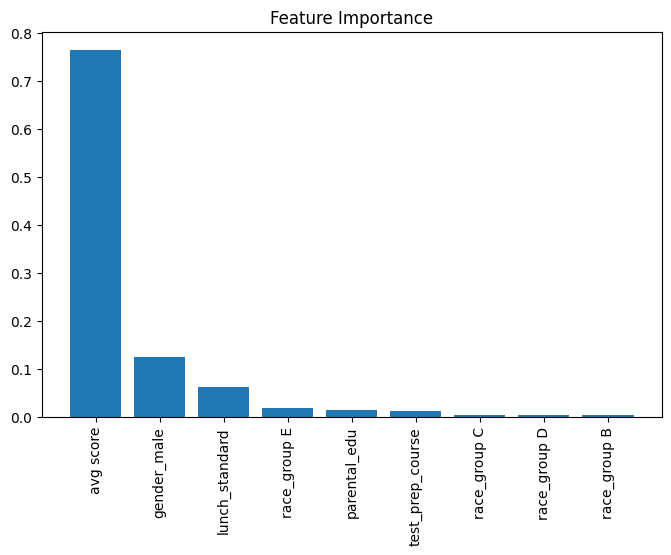

In [ ]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.title("Feature Importance")
plt.show()


In [ ]:
X = updated_studGrades[['avg score', 'gender_male', 'lunch_standard', 'race_group E']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_new_scores = model_evaluation(lr, X_train, y_train, X_test, y_test)
print_model_evaluation(*lr_scores)

Train MSE: 29.419768636472938
Test MSE: 28.891127407778782
Train R2: 0.8695050046172221
Test R2: 0.8812718115686682


In [ ]:
lr_diff = np.array(lr_scores) - np.array(lr_new_scores)
print_model_evaluation(*lr_diff)

Train MSE: -1.5931588188808377
Test MSE: -2.7275658740827105
Train R2: 0.007066651518671252
Test R2: 0.01120894143334017


* race_group B, C, D features are not important so we could delete them

###Best performance with linear regrission
  * Train MSE: 29.419768636472938
  * Test MSE: 28.891127407778786
  * Train R2: 0.8695050046172221
  * Test R2: 0.8812718115686682

##Observations
* we could make the model less complex by using **[avg score, gender_male, lunch_standard, race_group E]** features with realy small scrafice in model acuarcy.

    * Train MSE difference: -1.5931588188808377
    * Test MSE difference: -2.7275658740827105
    * Train R2 difference: 0.007066651518671252
    * Test R2 difference: 0.01120894143334017